In [1]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


# Monte-Carlo
Il metodo Monte-Carlo è stato introdotto per risolvere integrali di funzioni complesse, spesso con un gran numero di dimensioni. La risoluzione avviene estraendo numeri casuali, o pseudo-casuali, distribuiti uniformemente nell'intervallo di integrazione della funzione. 

La generazione di numeri casuali è molto complessa e può essere ottenuta da processi naturali, come il decadimento radioattivo. Quando una sequenza di numeri casuali viene generata da un computer, si parla più correttamente di numeri **pseudo-casuali**, perché gli algoritmi utilizzati sono intrinsecamente deterministici per la natura deterministica dei processori.

L'integrazione di Monte-Carlo prevede di considerare il valore di un integrale come un valore medio della funzione integranda $f$ sul dominio di integrazione: $I=(b-a)\cdot\bar{f}$. Dopo aver generato $N$ punti uniformemente distribuiti nell'intervallo $[a,b]$ si utilizza lo stimatore di Monte-Carlo: $$I\approx \frac{b-a}{N}\sum_{i=1}^{N}f(x_i),$$ dove gli $x_i$ sono i numeri generati.

Per valutare la bontà della stima, si calcola l'errore sullo stimatore. Dopo aver ottenuto la deviazione standard della funzione $f(x)$ sulla distribuzione uniforme, si calcola l'errore utilizzando la seguente formula: $$\sigma_I = \frac{b-a}{\sqrt{N}}\sigma_f.$$

# Metropolis
Quando viene generato una sequenza di numeri pseudo-casuali, si ottiene una serie di valori che coprono un intervallo molto più ampio di quello di interesse. L'ideale sarebbe generare la sequenza seguendo la distribuzione desiderata, ma questa non sempre è nota a priori. Per ovviare a questo problema si utilizza il cosiddetto *importance sampling*, cioè si campionano configurazioni che seguono la distribuzione di Boltzmann: $$P(\mathcal{C})=\frac{1}{Z}\exp\left(-\frac{E(\mathcal{C})}{k_B T}\right)$$ con $\mathcal{C}$ configurazione, $Z$ funzione di partizione, $k_B$ costante di Boltzmann, $T$ temperatura e $E(\mathcal{C})$ energia della configurazione considerata.

Con l'algoritmo di Metropolis vengono generate delle configurazioni che tendono alla distribuzione di Boltzmann. Presa una griglia di spin orientati in modo totalmente arbitrario, viene scelto un sito e cambiato il valore di spin, creando così una nuova configurazione $\mathcal{C}'$. Si calcola la variazione di energia a seguito di tale cambiamento e si implementa una regola di accettazione della configurazione:
- se la variazione di energia $\Delta E$ è minore o uguale a zero, cioè il sistema sta passando ad una configurazione ad energia minore, il cambiamento viene sempre accettato;
- in caso contrario, il cambiamento viene accettato se, estratto un numero $r$ uniforme nell'intervallo $[0,1)$, questo è minore di $\exp(-\Delta E/k_B T)$.

Questo meccanismo di accettazione permette di spostarsi sempre verso stati a bassa energia, mentre lo spostamento verso stati ad alta energia è permesso quasi solo quando la temperatura è molto alta ($T>T_C con T_C=2.269$ per sistemi bidimensionali - Onsager(1944)), infatti per $T$ molto alta si ha $exp(-\Delta E/k_B T)\approx 1$ e quindi il numero $r$ è quasi sempre minore del valore dell'esponenziale e il sistema ha la possibilità di esplorare lo spazio delle configurazioni.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
plt.rcParams["figure.figsize"] = [12, 7.42]

In [3]:
N = 100000
rngs = np.random.rand(N)
means = np.zeros_like(rngs)

In [4]:
for i in range(len(rngs)):
    means[i] = np.mean(rngs[:i])
means = means[10:]

/home/nico/Scrivania/comp_phy/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nico/Scrivania/comp_phy/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


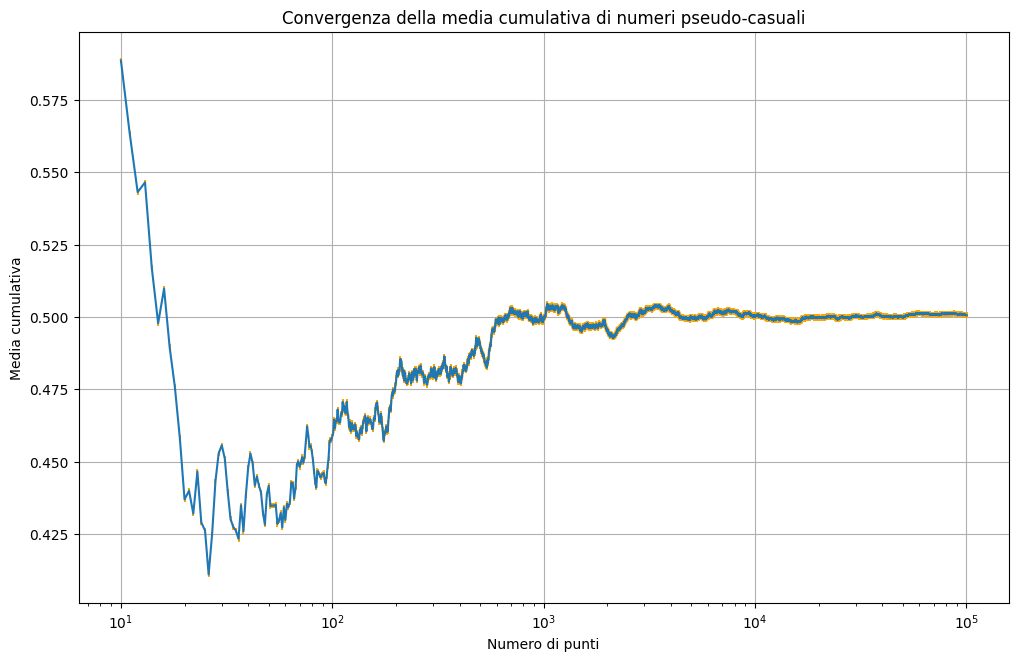

In [21]:
plt.errorbar(
    [x for x in range(10, N)],
    means,
    yerr=1/np.sqrt(12*N),
    ecolor="orange",
    markersize=5
)
plt.title("Convergenza della media cumulativa di numeri pseudo-casuali")
plt.xscale("log")
plt.xlabel("Numero di punti")
plt.ylabel("Media cumulativa")
plt.grid()
plt.show()

Dopo aver generato $N=10^5$ numeri pseudo-casuali nell'intervallo $[0,1)$, è stata calcolata la media cumulativa al crescere di $N$ ed è stata graficata in funzione di $N$. Si nota come dopo circa $10^3$ punti, la media tenda al valore teorico di $0.5$. In arancione è mostrato l'errore teorico $\sigma/\sqrt{N}$.

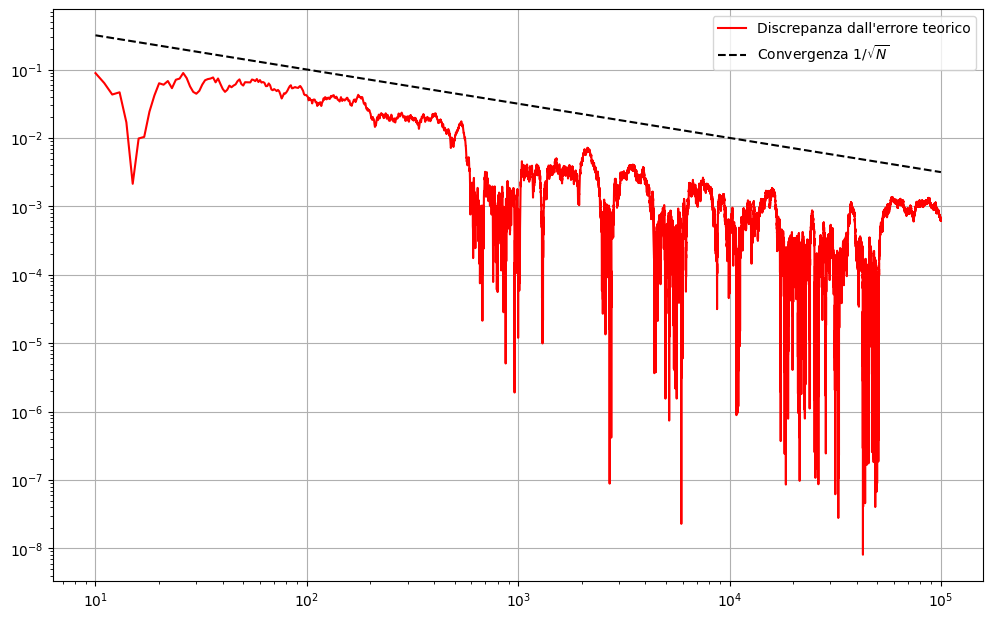

In [20]:
N_th = np.arange(10, len(means)+10)
err_th = 1 / np.sqrt(N_th)
plt.loglog(N_th, np.abs(means-0.5), color="red", label="Discrepanza dall'errore teorico")
plt.plot(N_th, err_th, "--", color="black", label=r"Convergenza $1/\sqrt{N}$")
plt.grid()
plt.legend()
plt.show()

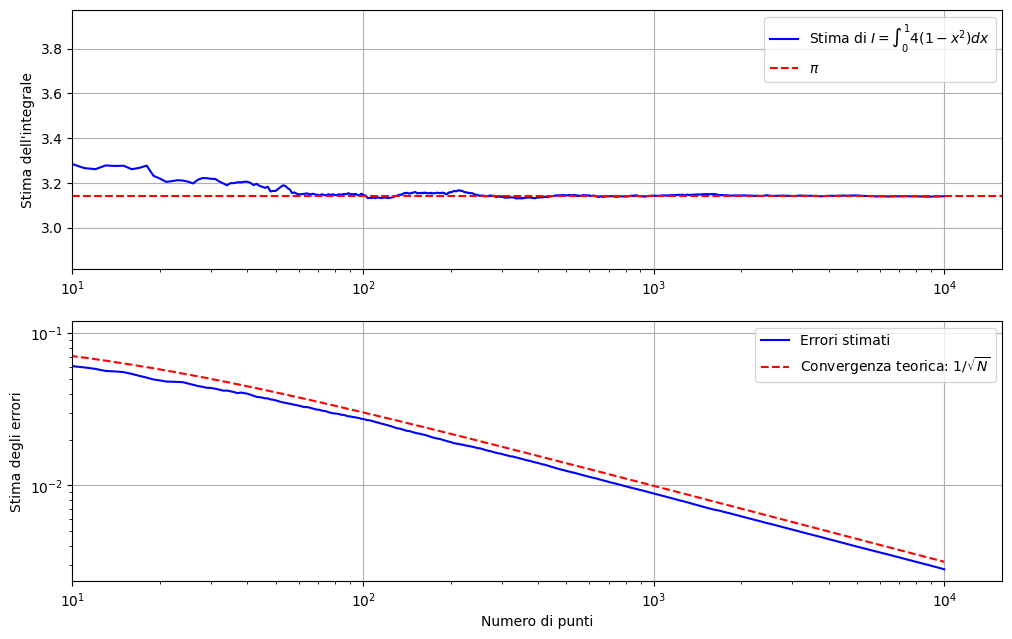

In [23]:
def f(x):
    return 4 * np.sqrt(1 - x**2)

def stimatore(rng: list[float], f: callable) -> float:
    return np.mean(f(rng))

Ns = np.linspace(1, 100_000, 10000).astype(int)
stime = np.zeros(len(Ns))
errs = np.zeros(len(Ns))

for i in range(len(Ns)):
    rng = rngs[:Ns[i]]
    stime[i] = stimatore(rng, f)
    sigma_f = np.std(f(rng))
    errs[i] = sigma_f / np.sqrt(Ns[i])

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(stime, color="blue", label=r"Stima di $I=\int_{0}^{1}4(1-x^2)dx$")
ax1.axhline(np.pi, ls="--", color="red", label=r"$\pi$")
ax1.set_xscale("log")
ax1.set_ylabel("Stima dell'integrale")
ax1.grid(True)
ax1.legend()
ax1.set_xlim(left=10)
ax2.plot(errs[10:], color="blue", label="Errori stimati")
ax2.plot(1/np.sqrt(Ns[10:]), "--", color="red", label=r"Convergenza teorica: $1/\sqrt{N}$")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Numero di punti")
ax2.set_ylabel("Stima degli errori")
ax2.grid(True)
ax2.set_xlim(left=10)
ax2.legend()
plt.show()

In [27]:
rng = np.random.default_rng(seed=42)
def metropolis(lattice, J, T, N, even_mask):
    kb = 1.0
    # even_mask ha true in caselle alternate, come una scacchiera; ~even_mask è la sua negazione
    # quindi ha true nelle caselle shiftate di un posto
    for s in [even_mask, ~even_mask]:
        neig_sum = np.roll(lattice, shift=1, axis=0) + np.roll(lattice, shift=-1, axis=0) + np.roll(lattice, shift=1, axis=1) + np.roll(lattice, shift=-1, axis=1)
        de = np.zeros_like(lattice)
        de_s = 2 * J * lattice[s] * neig_sum[s]
        prob = np.exp(-de_s/(kb*T))
        # sto condensando la condizione di accettazione del flip
        # sempre accettata se la variazione di energia è negativa
        # oppure se maggiore di un numero pseudo-random in [0,1]
        accept = (de_s <= 0) | (rng.random(de_s.shape) < prob)
        # considero solo i siti della maschera attuale e se la condizione è vera
        # accept=True, allora cambio il segno dei siti (flippo gli spin), 
        # altrimenti li lascio con il loro valore
        lattice[s] = np.where(accept, -lattice[s], lattice[s])

In [9]:
def total_energy(lattice, L, J):
    neig_sum = np.roll(lattice, shift=1, axis=0) + np.roll(lattice, shift=-1, axis=0) + np.roll(lattice, shift=1, axis=1) + np.roll(lattice, shift=-1, axis=1)
    return -J * np.sum(lattice * neig_sum) / 2

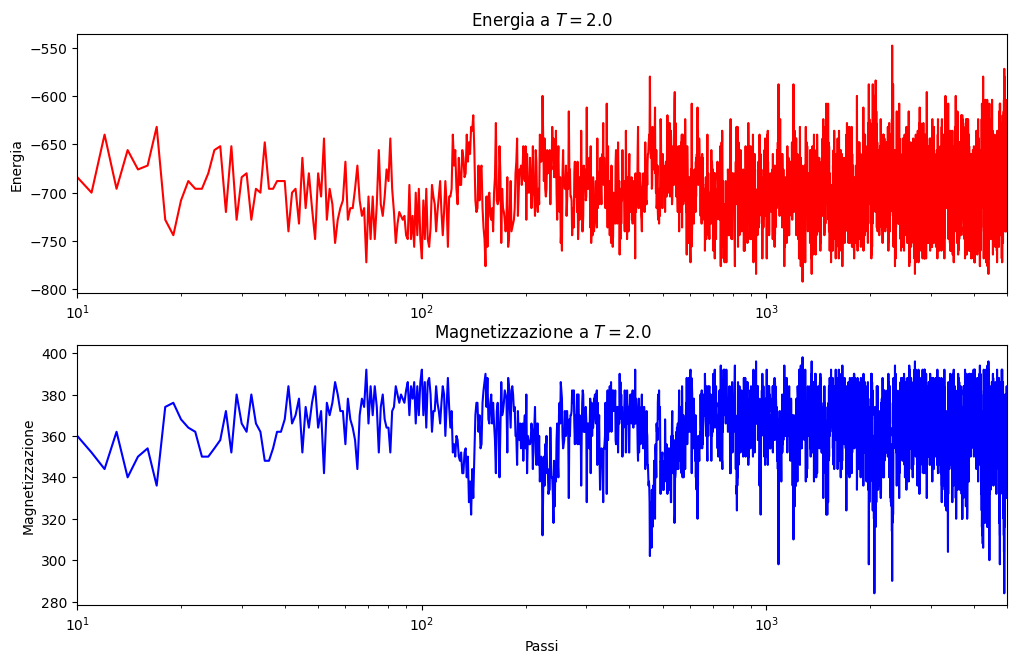

In [31]:
L = 20
J, T = 1.0, 2.0
even_mask = np.zeros((L,L), dtype=bool)
even_mask[::2, ::2] = True # sto considerando le colonne pari e le righe pari
even_mask[1::2, 1::2] = True # sto considerando le colonne dispari e le righe dispari
term_steps = 3000
measure_steps = 5000

lattice = np.random.choice([-1,1], size=(L, L))

for step in range(term_steps):
    # faccio agire metropolis sulle due maschere in modo che visiti tutti i punti della griglia
    metropolis(lattice, J, T, L, even_mask)
    metropolis(lattice, J, T, L, ~even_mask)

energies = np.zeros(measure_steps)
magn = np.zeros(measure_steps)

for step in range(measure_steps):    
    metropolis(lattice, J, T, L, even_mask)
    metropolis(lattice, J, T, L, ~even_mask)

    energies[step] = total_energy(lattice, L, J)
    magn[step] = np.sum(lattice)

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(energies, color="red", label=rf"Energia a $T={T}$")
ax1.set_xscale("log")
ax1.set_xlim(left=10, right=measure_steps)
ax1.set_title(rf"Energia a $T={T}$")
ax1.set_ylabel("Energia")

ax2.plot(magn, color="blue", label=rf"Magnetizzazione a $T={T}$")
ax2.set_xscale("log")
ax2.set_xlim(left=10, right=measure_steps)
ax2.set_title(rf"Magnetizzazione a $T={T}$")
ax2.set_xlabel("Passi")
ax2.set_ylabel("Magnetizzazione")
plt.show()

Dato che il sistema è alla temeperatura $T=2.0$ che è minore ma abbastanza vicina a quella critica $T=2.269$, si può notare come sia l'energia totale che la magnetizzazione totale oscillino perché non è più possibile una configurazione ferromagnetica con gli spin allineati in un verso. Nel grafico seguente si nota il comportamento di queste due grandezze quando il sistema si trova alla temperatura critica: il sistema si trova in uno stato formato da domini di minimo di energia e non riesce ad uscirne.

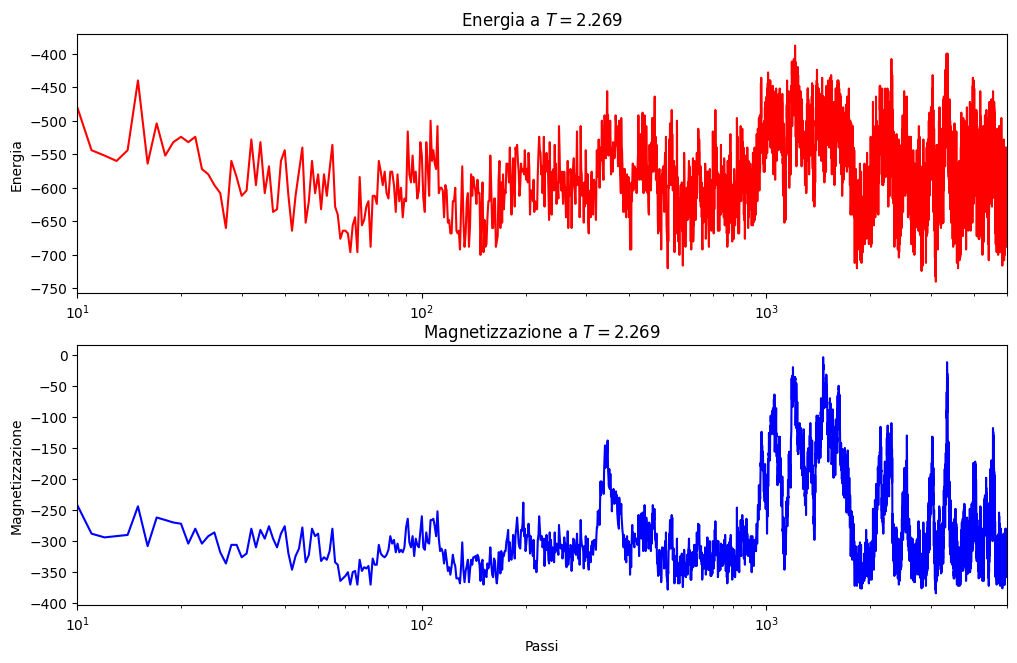

In [33]:
T = 2.269
for step in range(term_steps):
    # faccio agire metropolis sulle due maschere in modo che visiti tutti i punti della griglia
    metropolis(lattice, J, T, L, even_mask)
    metropolis(lattice, J, T, L, ~even_mask)

energies = np.zeros(measure_steps)
magn = np.zeros(measure_steps)

for step in range(measure_steps):    
    metropolis(lattice, J, T, L, even_mask)
    metropolis(lattice, J, T, L, ~even_mask)

    energies[step] = total_energy(lattice, L, J)
    magn[step] = np.sum(lattice)

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(energies, color="red", label=rf"Energia a $T={T}$")
ax1.set_xscale("log")
ax1.set_xlim(left=10, right=measure_steps)
ax1.set_title(rf"Energia a $T={T}$")
ax1.set_ylabel("Energia")

ax2.plot(magn, color="blue", label=rf"Magnetizzazione a $T={T}$")
ax2.set_xscale("log")
ax2.set_xlim(left=10, right=measure_steps)
ax2.set_title(rf"Magnetizzazione a $T={T}$")
ax2.set_xlabel("Passi")
ax2.set_ylabel("Magnetizzazione")
plt.show()

In [11]:
temps = np.array([1.0, 1.5, 2.0, 2.2, 2.3, 2.4, 2.5, 3.0, 4.0])
mean_en = np.zeros_like(temps)
mean_magn = np.zeros_like(temps)
term_steps, measure_steps = 100*L, 300*L


for i in range(len(temps)):
    lattice = np.random.choice([-1,1], size=(L,L))
    
    for _ in range(term_steps):
        metropolis(lattice, J, temps[i], L, even_mask)
        metropolis(lattice, J, temps[i], L, ~even_mask)

    
    energies = np.zeros(measure_steps)
    magn = np.zeros(measure_steps)
    for step in range(measure_steps):
        metropolis(lattice, J, temps[i], L, even_mask)
        metropolis(lattice, J, temps[i], L, ~even_mask)

        energies[step] = total_energy(lattice, L, J)
        magn[step] = np.sum(lattice)

    mean_en[i] = np.mean(energies) / (L**2)
    mean_magn[i] = np.mean(np.abs(magn)) / (L**2)

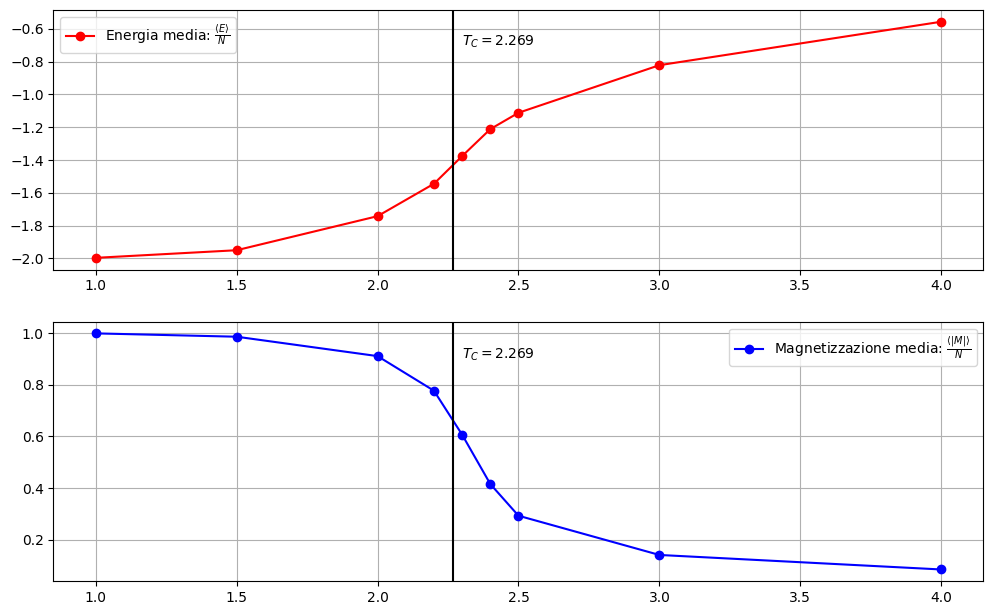

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(temps, mean_en, "-o", color="red", label=r"Energia media: $\frac{\langle E \rangle}{N}$")
ax1.axvline(2.269, color="black")
ax1.text(2.3, -0.7, s=r"$T_C=2.269$")
ax1.legend()
ax1.grid()

ax2.plot(temps, mean_magn, "-o", color="blue", label=r"Magnetizzazione media: $\frac{\langle |M| \rangle}{N}$")
ax2.axvline(2.269, color="black")
ax2.text(2.3, 0.9, s=r"$T_C=2.269$")
ax2.legend()
ax2.grid()

plt.show()

Variando la temperatura in un intorno della temperatura critica, si nota come il sistema passi da una configurazione ferromagnetica ordinata ($m=1$) con bassa energia media per sito ($e=-2.0$) ad una configurazione paramagnetica disordinata ($m\approx0.1$) con alta energia media per sito ($e=-0.6$).

In [35]:
low_lattice = np.random.choice([-1,1], size=(L,L))
crit_lattice = np.random.choice([-1,1], size=(L,L))
high_lattice = np.random.choice([-1,1], size=(L,L))
CMAP = ListedColormap(["red", "blue"])
term_steps, measure_steps = 7500, 2000

for _ in range(term_steps):
    metropolis(low_lattice, J, 1.0, L, even_mask)
    metropolis(low_lattice, J, 1.0, L, even_mask)
    metropolis(crit_lattice, J, 2.269, L, even_mask)
    metropolis(crit_lattice, J, 2.269, L, even_mask)
    metropolis(high_lattice, J, 4.0, L, even_mask)
    metropolis(high_lattice, J, 4.0, L, even_mask)

for _ in range(measure_steps):
    metropolis(low_lattice, J, 1.0, L, even_mask)
    metropolis(low_lattice, J, 1.0, L, even_mask)
    metropolis(crit_lattice, J, 2.269, L, even_mask)
    metropolis(crit_lattice, J, 2.269, L, even_mask)
    metropolis(high_lattice, J, 4.0, L, even_mask)
    metropolis(high_lattice, J, 4.0, L, even_mask)

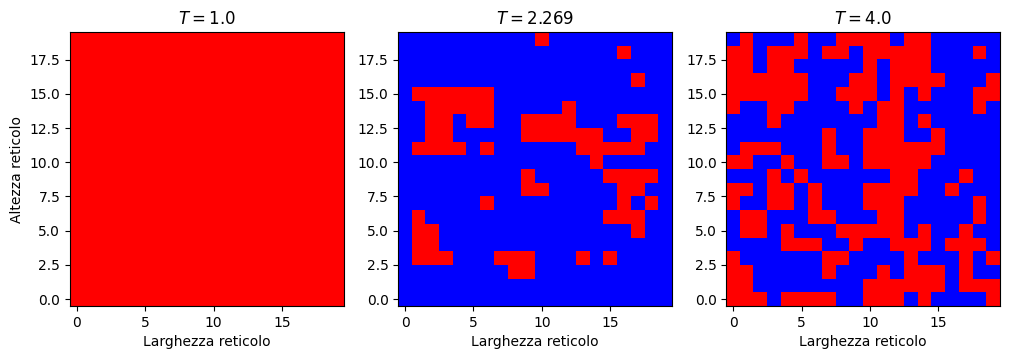

In [39]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
ax1.imshow(low_lattice, cmap=CMAP, origin="lower")
ax1.set_ylabel("Altezza reticolo")
ax1.set_xlabel("Larghezza reticolo")
ax1.set_title(r"$T=1.0$")
ax2.imshow(crit_lattice, cmap=CMAP, origin="lower")
ax2.set_xlabel("Larghezza reticolo")
ax2.set_title(r"$T=2.269$")
ax3.imshow(high_lattice, cmap=CMAP, origin="lower")
ax3.set_xlabel("Larghezza reticolo")
ax3.set_title(r"$T=4.0$")
plt.show()

Infine, si analizzano le tre diverse configurazioni della griglia a temperature diverse. 

Per $T<T_C$ (bassa temperatura) si ottiene una configurazione ferromagnetica ordinata in cui tutti gli spin hanno lo stesso verso. Per $T>T_C$ (alta temperatura) il sistema è in una configurazione paramagnetica in cui gli spin sono orientati casualmente. 
Infine, alla temperatura critica $T_C$ il sistema mostra la formazione di domini di spin e non si trova in un unico minimo globale di energia. Una leggera variazione della temperatura permetterebbe al sistema di evolvere in una configurazione ordinata o di dissolversi in una configurazione disordinata.